<a href="https://colab.research.google.com/github/JakeOh/202605_BD57/blob/main/lab_ml/ml04_cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

유방암 데이터 셋에서 양성/음성 분류

# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets  # 예제 데이터 셋 모듈. load_xyz() 함수들.
from sklearn.model_selection import train_test_split  # 훈련 셋 vs 테스트 셋 분리
from sklearn.preprocessing import StandardScaler  # 표준화 특성 스케일러
from sklearn.neighbors import KNeighborsClassifier  # KNN 분류 모델
from sklearn.metrics import classification_report, confusion_matrix  # 평가 지표

# Breast Cancer 데이터 셋

In [2]:
# scikit-learn 패키지의 예제 데이터 셋 가져오기
cancer = datasets.load_breast_cancer()

In [4]:
print(type(cancer))

<class 'sklearn.utils._bunch.Bunch'>


scikit-learn 패키지의 `Bunch` 클래스:

*   파이썬의 `dict`와 비슷한 클래스
*   key-value 쌍으로 아이템들을 저장.
*   `bunch_name['key']` 또는 `bunch_name.key` 형식으로 키(key)를 사용해서 값(value)을 참조할 수 있음.

In [5]:
cancer.keys()  # Bunch 객체의 키들.

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [7]:
# 데이터 셋 설명(description)
print(cancer.DESCR)  # print(cancer['DESCR'])

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [8]:
print(cancer.target_names)
#> 0 -> malignant(양성, 악성 암), 1 -> benign(음성, 암이 아님.)

['malignant' 'benign']


In [9]:
print(cancer.feature_names)  #> 특성 이름들. 데이터프레임의 컬럼 이름들.

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [10]:
x = cancer.data  # 특성 배열(2차원 배열)
y = cancer.target  # 타겟 배열(1차원 배열)

In [11]:
x.shape  # (n_samples, n_features) = (539, 30): 539개 진단 데이터, 30개의 변수(컬럼).

(569, 30)

In [12]:
y.shape  # (n_sample,) = (539,): 539개 데이터의 레이블들

(569,)

In [13]:
x[:2]

array([[1.799e+01, 1.038e+01, 1.228e+02, 1.001e+03, 1.184e-01, 2.776e-01,
        3.001e-01, 1.471e-01, 2.419e-01, 7.871e-02, 1.095e+00, 9.053e-01,
        8.589e+00, 1.534e+02, 6.399e-03, 4.904e-02, 5.373e-02, 1.587e-02,
        3.003e-02, 6.193e-03, 2.538e+01, 1.733e+01, 1.846e+02, 2.019e+03,
        1.622e-01, 6.656e-01, 7.119e-01, 2.654e-01, 4.601e-01, 1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, 1.326e+03, 8.474e-02, 7.864e-02,
        8.690e-02, 7.017e-02, 1.812e-01, 5.667e-02, 5.435e-01, 7.339e-01,
        3.398e+00, 7.408e+01, 5.225e-03, 1.308e-02, 1.860e-02, 1.340e-02,
        1.389e-02, 3.532e-03, 2.499e+01, 2.341e+01, 1.588e+02, 1.956e+03,
        1.238e-01, 1.866e-01, 2.416e-01, 1.860e-01, 2.750e-01, 8.902e-02]])

In [14]:
y[:2]

array([0, 0])

In [15]:
y[-2:]

array([0, 1])

In [16]:
# 0(malignant) vs 1(benign)의 비율
pd.Series(y).value_counts()

,count
1,357
0,212


## 훈련 셋 vs 테스트 셋 분리

In [19]:
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size=0.3,
                                                    random_state=42,
                                                    stratify=y)

In [20]:
x_train.shape

(398, 30)

In [21]:
x_test.shape

(171, 30)

In [22]:
y_train.shape

(398,)

In [23]:
y_test.shape

(171,)

In [24]:
pd.Series(y).value_counts(normalize=True)

,proportion
1,0.627417
0,0.372583


In [25]:
pd.Series(y_train).value_counts(normalize=True)

,proportion
1,0.628141
0,0.371859


In [26]:
pd.Series(y_test).value_counts(normalize=True)

,proportion
1,0.625731
0,0.374269


## 데이터 전처리(표준화)

In [27]:
# 표준화 스케일링을 수행하는 변환기 객체 생성
scaler = StandardScaler()

In [29]:
# 훈련 셋 스케일링(표준화)
# fit() 메서드 - 훈련 셋의 특성들의 평균, 분산(표준편차)를 찾음.
# transform() 메서드 - 찾은 평균과 표준편차들을 사용해서 표준화를 실행(변환).
# fit_transform() 메서드 - 훈련 셋에서 평균과 표준편차들을 찾고, 변환(스케일링)까지 수행.
# (주의) fit 또는 fit_transform 메서드의 아규먼트는 훈련 셋만. 테스트 셋을 아규먼트로 주면 안됨!
# transform 메서드는 fit 또는 fit_transform 메서드가 호출된 다음에만 호출.
x_tr_scaled = scaler.fit_transform(X=x_train)

In [30]:
x_tr_scaled[:2]  #> 스케일 변환된 특성 배열

array([[-0.70982078, -0.258417  , -0.63739619, -0.71199581,  1.62843044,
         0.84728866,  0.16650073,  0.19641954,  0.54271642,  1.3471506 ,
         0.07888449,  1.00097591,  0.14862676, -0.30247042,  2.51058541,
         0.35861242,  0.52155906,  1.08389476, -0.29885498,  0.48535309,
        -0.60006823, -0.06586747, -0.56566159, -0.62261349,  2.01922243,
         0.18620235,  0.18018746,  0.40093281, -0.41407439,  0.44522333],
       [-0.83033136,  2.2311266 , -0.87497994, -0.7790808 , -1.59756876,
        -1.26771706, -1.08647139, -1.24323171, -2.65854287, -1.05269949,
        -0.33760049,  4.98258297, -0.4296651 , -0.44954246,  0.20210656,
        -0.88251048, -0.96334097, -1.8171767 , -0.09058754, -0.69943637,
        -0.89736062,  1.97515343, -0.94957443, -0.7793308 , -1.74765214,
        -1.22937204, -1.25894675, -1.69278836, -2.09572345, -1.32341746]])

In [31]:
scaler.mean_  #> 30개 특성(변수)의 평균들

array([1.40938467e+01, 1.93415327e+01, 9.16989447e+01, 6.50784171e+02,
       9.57892714e-02, 1.03143442e-01, 8.84457681e-02, 4.80487286e-02,
       1.80492965e-01, 6.27095729e-02, 3.91917085e-01, 1.19798166e+00,
       2.77358819e+00, 3.82153342e+01, 6.98150251e-03, 2.53617487e-02,
       3.21848910e-02, 1.15316784e-02, 2.06816231e-02, 3.80615352e-03,
       1.62665603e+01, 2.58163065e+01, 1.07220678e+02, 8.79696734e+02,
       1.32259095e-01, 2.57169975e-01, 2.78709540e-01, 1.14484601e-01,
       2.92937688e-01, 8.42292211e-02])

In [32]:
scaler.var_  #> 30개 특성의 분산들

array([1.21464164e+01, 2.02032250e+01, 5.77615403e+02, 1.15509855e+05,
       1.77750313e-04, 2.84039582e-03, 6.62700848e-03, 1.49368716e-03,
       7.85132915e-04, 5.33575161e-05, 5.31304841e-02, 2.93211310e-01,
       2.90709798e+00, 1.17435879e+03, 9.18433682e-06, 3.48876908e-04,
       1.11620516e-03, 4.02708432e-05, 7.63659923e-05, 8.44975108e-06,
       2.34615878e+01, 3.99470318e+01, 1.13782180e+03, 3.18898596e+05,
       5.13146266e-04, 2.70597884e-02, 4.90104788e-02, 4.57392265e-03,
       4.23217783e-03, 3.61985240e-04])

In [33]:
# 테스트 셋 스케일 변환(표준화)
# 테스트 셋은 훈련 셋의 평균과 표준편차를 사용해서 스케일 변환하기 때문에, transform 메서드만 호출!
x_te_scaled = scaler.transform(X=x_test)

## KNN 모델 생성, 훈련, 평가

In [34]:
# KNN 모델 생성
knn = KNeighborsClassifier()

In [35]:
# KNN 모델을 전처리가 끝난 훈련 셋으로 학습시킴
knn.fit(X=x_tr_scaled, y=y_train)

KNeighborsClassifier()

### 훈련 셋 평가

In [36]:
# 훈련 셋(학습된 데이터) 정확도
knn.score(X=x_tr_scaled, y=y_train)

0.9723618090452262

In [37]:
# 훈련 셋(학습된 데이터)의 예측값
train_pred = knn.predict(X=x_tr_scaled)

In [38]:
train_pred[:20]

array([1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1])

In [39]:
y_train[:20]  # 실젯값

array([1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1])

In [41]:
train_report = classification_report(y_true=y_train, y_pred=train_pred,
                                     target_names=cancer.target_names)
print(train_report)

              precision    recall  f1-score   support

   malignant       0.99      0.94      0.96       148
      benign       0.96      0.99      0.98       250

    accuracy                           0.97       398
   macro avg       0.98      0.97      0.97       398
weighted avg       0.97      0.97      0.97       398



In [42]:
# 혼동 행렬(confusion matrix)
tr_conf_mat = confusion_matrix(y_true=y_train, y_pred=train_pred)
print(tr_conf_mat)

[[139   9]
 [  2 248]]


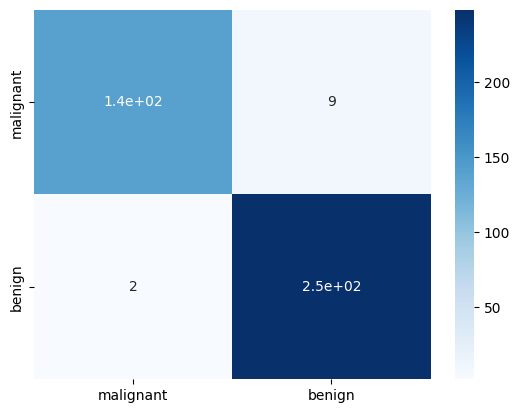

In [52]:
# 혼동 행렬 히트 맵(heat map)
sns.heatmap(data=tr_conf_mat, cmap='Blues', annot=True,
            xticklabels=cancer.target_names, yticklabels=cancer.target_names)
plt.show()

### 테스트 셋 평가

In [53]:
# 테스트 셋(학습되지 않은 데이터)의 정확도
knn.score(X=x_te_scaled, y=y_test)

0.9590643274853801

In [54]:
# 테스트 셋 예측값
test_pred = knn.predict(X=x_te_scaled)

In [56]:
test_report = classification_report(y_true=y_test, y_pred=test_pred,
                                    target_names=cancer.target_names)
print(test_report)

              precision    recall  f1-score   support

   malignant       1.00      0.89      0.94        64
      benign       0.94      1.00      0.97       107

    accuracy                           0.96       171
   macro avg       0.97      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



In [57]:
# 테스트 셋 혼동 행렬
te_conf_mat = confusion_matrix(y_true=y_test, y_pred=test_pred)
print(te_conf_mat)

[[ 57   7]
 [  0 107]]


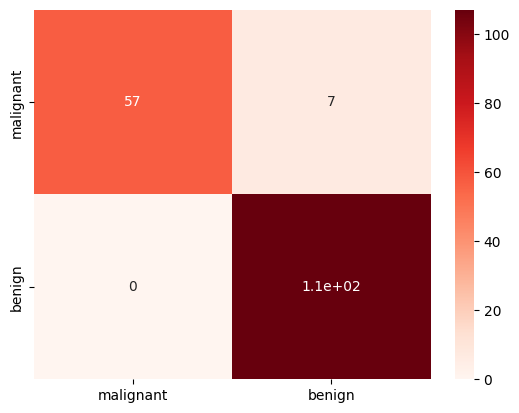

In [61]:
sns.heatmap(data=te_conf_mat, cmap='Reds', annot=True,
            xticklabels=cancer.target_names, yticklabels=cancer.target_names)
plt.show()

## 하이퍼파라미터 튜닝(최적의 k 값)

*   k 값을 1 ~ 100 바꿔가면서
    *   KNN 모델을 전처리가 된 훈련 셋으로 학습.
    *   훈련 셋 vs 테스트 셋 정확도.
    *   k 값에 따른 정확도를 시각화.

In [62]:
k_values = np.arange(1, 101)  # n_neighbors 파라미터로 사용할 값들.
train_accuracies = []  # 훈련 셋에서의 정확도를 저장하기 위한 리스트.
test_accuracies = []  # 테스트 셋에서의 정확도를 저장하기 위한 리스트.
for k in k_values:  # 1 ~ 100 반복
    knn = KNeighborsClassifier(n_neighbors=k)  # KNN 모델 생성
    knn.fit(X=x_tr_scaled, y=y_train)  # KNN 모델 훈련
    tr_acc = knn.score(X=x_tr_scaled, y=y_train)  # 훈련 셋에서의 정확도
    train_accuracies.append(tr_acc)
    te_acc = knn.score(X=x_te_scaled, y=y_test)  # 테스트 셋에서의 정확도
    test_accuracies.append(te_acc)

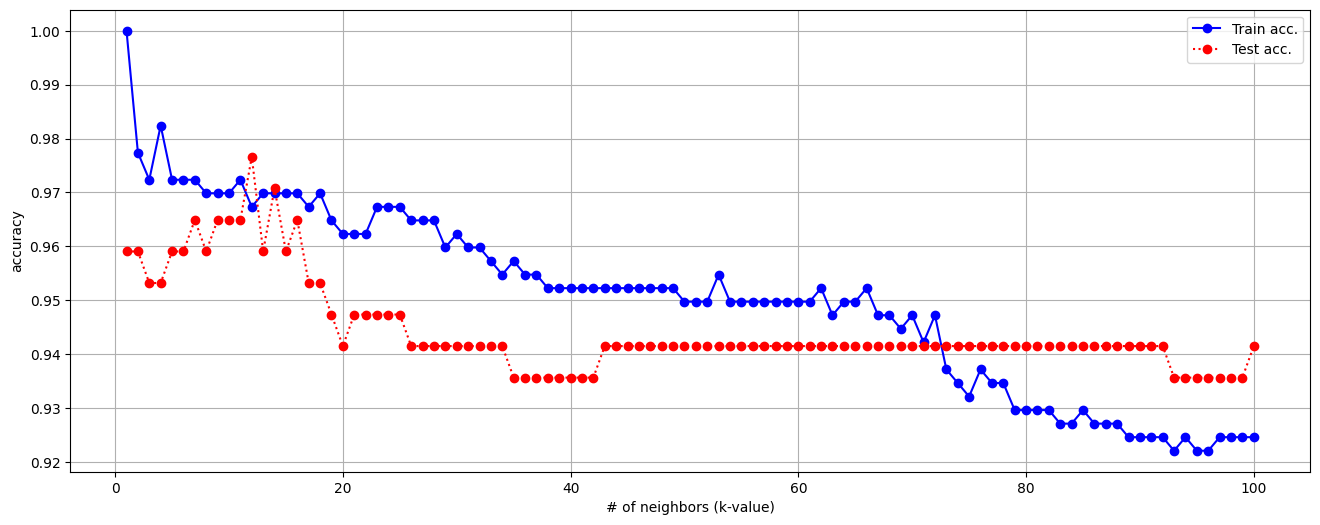

In [69]:
plt.figure(figsize=(16, 6))

# 훈련 셋 정확도 시각화
plt.plot(k_values, train_accuracies, 'bo-', label='Train acc.')

# 테스트 셋 정확도 시각화
plt.plot(k_values, test_accuracies, 'ro:', label='Test acc.')

plt.legend()
plt.grid()
plt.xlabel('# of neighbors (k-value)')
plt.ylabel('accuracy')

plt.show()